# Introduction to EEG Signal Processing

This notebook walks through a simple EEG analysis workflow in Python, from loading a recording to extracting basic spectral features and visualizing them across the scalp.

We use [MNE-Python](https://mne.tools/stable/index.html), a widely used library for EEG and MEG analysis. It provides tools for loading data, preprocessing, visualization, spectral analysis, epoching, and many more advanced workflows.

The goal here is to build intuition and give you a clean starting point for your own EEG analyses.

In this example, we are using an EEG eyes-closed resting-state data

NOTE: If you would like to make changes and test the code, please make a copy of the file (named Your_Name_EEG_Introduction.ipynb for example). Do NOT modify this file.


## Notebook roadmap

1. Connect Google Drive
2. Import libraries
3. Load the EEG data
4. Inspect the raw recording
5. Apply basic preprocessing
6. Compare raw and cleaned time series
7. Compute and visualize the PSD
8. Extract band-power features
9. Plot topographic maps of band power

The emphasis is on understanding the main steps, not covering every preprocessing option in detail.


## 1. Connect Google Drive

If you are running this notebook in Google Colab, you first need to mount Google Drive so the notebook can access your EEG files.

After running the cell below and approving access, your Drive files will be available under:

`/content/drive/MyDrive/`


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Import libraries

We will use a small set of libraries throughout the notebook:

- `mne` for loading, preprocessing, and analyzing EEG data
- `numpy` for numerical operations
- `pandas` for organizing extracted features into tables
- `matplotlib` for plotting signals, spectra, and scalp maps
- `Path` for working with file paths in a readable way


In [ ]:
# EEG analysis library
!pip install -q mne
import mne
from mne.preprocessing import ICA


# Numerical and data handling libraries
import numpy as np
import pandas as pd

# Plotting library
import matplotlib.pyplot as plt

# File path handling
from pathlib import Path

# Visualization
from matplotlib.patches import Patch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 55.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


## 3. Loading the data

EEG recordings can come in several formats, including `.set`, `.edf`, `.vhdr`, `.fif`, and `.bdf`.

In this notebook, we load an EEGLAB `.set` file with MNE-Python. If your data uses a different format, use the corresponding loading function shown in the comments below.

Before running the next cell, update the data path so it points to the folder where your file is stored.


In [ ]:
# MODIFY TO YOUR PATH NAME
data_dir = Path("/content/drive/MyDrive/EEG Analysis/Data")

# Example: path to your EEG file
eeg_file = data_dir / "Copy of MED_PBM_009_Cond1_DURING_RELAX.set"

# Load EEGLAB .set file
raw = mne.io.read_raw_eeglab(eeg_file, preload=True)

# Other common EEG file formats:
# raw = mne.io.read_raw_edf(data_dir / "example_file.edf", preload=True)
# raw = mne.io.read_raw_brainvision(data_dir / "example_file.vhdr", preload=True)
# raw = mne.io.read_raw_fif(data_dir / "example_file_raw.fif", preload=True)
# raw = mne.io.read_raw_bdf(data_dir / "example_file.bdf", preload=True)

# Display basic information about the loaded EEG data
print(raw)

Reading /content/drive/MyDrive/EEG Analysis/Data/Copy of MED_PBM_009_Cond1_DURING_RELAX.fdt


/tmp/ipykernel_1966/1437590761.py:8: RuntimeWarning: Data file name in EEG.data (MED_PBM_009_Cond1_DURING_RELAX.fdt) is incorrect, the file name must have changed on disk, using the correct file name (Copy of MED_PBM_009_Cond1_DURING_RELAX.fdt).
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)


Reading 0 ... 610999  =      0.000 ...  1221.998 secs...
<RawEEGLAB | Copy of MED_PBM_009_Cond1_DURING_RELAX.fdt, 60 x 611000 (1222.0 s), ~279.8 MiB, data loaded>


/tmp/ipykernel_1966/1437590761.py:8: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)
/tmp/ipykernel_1966/1437590761.py:8: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)


In [ ]:
# This command gives you basic information, such as number of EEG channels and sampling frequency
raw.info

# sfreq = raw.info['sfreq']

<Info | 8 non-empty values
 bads: []
 ch_names: FP1, FPZ, FP2, AF3, AF4, F7, F5, F3, F1, FZ, F2, F4, F6, F8, ...
 chs: 60 EEG
 custom_ref_applied: False
 dig: 63 items (3 Cardinal, 60 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 60
 projs: []
 sfreq: 500.0 Hz
>

## Basic preprocessing steps

EEG preprocessing is usually an iterative process: clean the data, inspect the result, and adjust if needed.

In this notebook, we use a simple baseline workflow:

1. Set electrode locations using a standard montage
2. Optionally downsample the data
3. Apply band-pass and notch filtering
4. Detect bad channels automatically
5. Re-reference the EEG channels
6. Use ICA to identify and remove some artifact-related components
7. Interpolate bad channels
8. Optionally divide the continuous data into fixed-length epochs

This example is intended as a practical introduction rather than a complete preprocessing pipeline. In real analyses, preprocessing may also include more steps and additional quality-control steps depending on the dataset and research question.

### Helper functions for preprocessing

These helper functions keep the main workflow easier to read.

They are used to:
- detect clearly problematic EEG channels with a simple automatic rule
- rename channels so they match standard MNE naming conventions


In [ ]:
def detect_bad_channels_simple(raw, z_thresh=3.5, delta_ratio_thresh=5):
    picks = mne.pick_types(raw.info, eeg=True, exclude=[])
    ch_names = [raw.ch_names[p] for p in picks]
    data = raw.get_data(picks=picks)

    def rz(x):
        med = np.median(x)
        mad = np.median(np.abs(x - med))
        return np.zeros_like(x) if mad == 0 else 0.6745 * (x - med) / mad

    # Variance outliers
    log_var = np.log10(np.var(data, axis=1) + 1e-20)
    var_z = rz(log_var)

    # Delta power outliers
    psd = raw.compute_psd(method="welch", fmin=0.5, fmax=40, picks=picks, verbose=False)
    psds, freqs = psd.get_data(return_freqs=True)

    delta_mask = (freqs >= 0.5) & (freqs <= 4)
    total_mask = (freqs >= 0.5) & (freqs <= 40)

    delta_power = np.trapezoid(psds[:, delta_mask], freqs[delta_mask], axis=1)
    total_power = np.trapezoid(psds[:, total_mask], freqs[total_mask], axis=1)
    delta_ratio = delta_power / (total_power + 1e-20)

    delta_z = rz(np.log10(delta_power + 1e-20))

    bad_channels = [
        ch_names[i]
        for i in range(len(ch_names))
        if abs(var_z[i]) > z_thresh
        or delta_z[i] > z_thresh
        or delta_ratio[i] > delta_ratio_thresh * np.median(delta_ratio)
    ]

    return bad_channels

def normalize_channel_names(raw):
    """Normalize common EEG channel names to match MNE standard montage naming."""

    rename_dict = {}

    for ch in raw.ch_names:
        ch_clean = ch.strip()
        ch_upper = ch_clean.upper()

        # Fp channels: FP1 -> Fp1, FP2 -> Fp2, FPZ -> Fpz
        if ch_upper.startswith("FP"):
            rename_dict[ch] = "Fp" + ch_upper[2:].lower()

        # Midline z channels: FZ -> Fz, CZ -> Cz, CPZ -> CPz, POZ -> POz
        elif ch_upper.endswith("Z"):
            rename_dict[ch] = ch_upper[:-1] + "z"

        # Other standard channels: AF3, F7, C3, P4, O1, etc.
        else:
            rename_dict[ch] = ch_upper

    raw.rename_channels(rename_dict)
    return raw

### Run preprocessing

The next cells apply the basic cleaning steps and create a cleaned version of the recording that we can inspect and analyze.


In [ ]:
# Make a copy of the raw data so the original recording stays unchanged
raw_clean = raw.copy()

# Set electrode locations
# The montage tells MNE where the EEG electrodes are located on the scalp.
# This is needed for topographic plots and bad-channel interpolation.
# raw_clean.drop_channels(['CB1', 'CB2']) # These channels were not found in the loaded data. Commenting.
raw_clean = normalize_channel_names(raw_clean)
montage = mne.channels.make_standard_montage("standard_1020")
raw_clean.set_montage(montage, on_missing="ignore")

# Optional: downsample the data to reduce file size and speed up processing.
# This is often unnecessary if the original sampling rate is already appropriate.
target_sfreq = 500
raw_clean.resample(target_sfreq)

# Band-pass filter the data.
# This keeps frequencies of interest while reducing slow drifts and high-frequency noise.
raw_clean.filter(l_freq=1, h_freq=100, picks="eeg")

# Apply a notch filter to reduce line noise, typically at 50 Hz or 60 Hz.
raw_clean.notch_filter(freqs=60)

# Detect bad channels.
# Bad channels may be noisy, flat, or unstable because of poor contact,
# movement, or electrode issues. Visual inspection is still important,
# but simple automated methods can provide a useful first pass.
bad_channels = detect_bad_channels_simple(raw_clean)

raw_clean.info["bads"] = bad_channels

print("Detected bad channels:", bad_channels)
print("All bad channels:", raw_clean.info["bads"])

# Re-reference the EEG to the average of all EEG channels.
# EEG is always measured relative to a reference, so this step affects the signal values.
raw_clean.set_eeg_reference("average", projection=False)

# Artifact removal with ICA
# EEG often contains non-neural activity such as eye or muscle artifacts.
# Here we use ICA to identify and remove some of these components.

# Create the ICA object
ica = ICA(
    n_components=0.99,
    method="infomax",
    fit_params=dict(extended=True),
    random_state=42,
    max_iter="auto"
)

# Fit ICA using only good EEG channels
picks = mne.pick_types(
    raw_clean.info,
    eeg=True,
    exclude="bads"
)

ica.fit(raw_clean, picks=picks)

# Try to identify components related to eye activity
try:
    eog_indices, eog_scores = ica.find_bads_eog(
        raw_clean,
        threshold=3.0
    )
except Exception as error:
    print("EOG detection failed:", error)
    eog_indices = []

# Try to identify components related to muscle activity
try:
    muscle_indices, muscle_scores = ica.find_bads_muscle(
        raw_clean,
        threshold=0.8
    )
except Exception as error:
    print("Muscle detection failed:", error)
    muscle_indices = []

# Combine all detected artifact components
artifact_indices = sorted(set(eog_indices + muscle_indices))

print("EOG components:", eog_indices)
print("Muscle components:", muscle_indices)
print("All artifact components to remove:", artifact_indices)

# Mark these components for removal
ica.exclude = artifact_indices

# Apply ICA cleaning to the data
raw_clean = ica.apply(raw_clean.copy())

print("ICA cleaning complete.")
print(f"Removed {len(artifact_indices)} components:", artifact_indices)

# Interpolate channels that were marked as bad.
# This restores the full channel layout, which is useful for scalp maps and later analyses.
raw_clean.interpolate_bads(reset_bads=True)

# Optional: split the continuous data into fixed-length epochs
epochs = mne.make_fixed_length_epochs(
    raw_clean,
    duration=5.0,
    overlap=0.0,
    preload=True,
    reject_by_annotation=True
)

Sampling frequency of the instance is already 500.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 1651 samples (3.302 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower trans

/tmp/ipykernel_1966/2314003493.py:99: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  raw_clean.interpolate_bads(reset_bads=True)


0 bad epochs dropped


As mentioned previously, this is a minimal preprocessing example designed to illustrate the main ideas.

In real EEG analyses, preprocessing is often more extensive and may include more robust bad-channel detection, ICA-based artifact correction, rejection of noisy segments or epochs, and additional quality-control steps.

For example, ICA can be combined with tools such as **ICLabel** to help classify components related to eye, muscle, heart, or other artifacts. Other useful approaches may include automated epoch rejection methods such as **AutoReject**, or more advanced denoising techniques depending on the recording setup and study design.

Several preprocessing pipelines and toolboxes also exist to support more standardized workflows, including:

- **pyPREP** for bad-channel detection and robust referencing
- **MNE-BIDS** for organizing EEG data and building reproducible analysis workflows
- **RELAX** (MATLAB) for automated EEG preprocessing
- **DISCOVER-EEG**
and many more

The best preprocessing strategy depends on the data quality, recording system, and research question, so this notebook should be seen as a simple starting point rather than a complete pipeline.

## Looking at time series

Time-domain plots are useful for checking signal quality before and after preprocessing.

As you inspect these figures, look for large artifacts, unusually noisy channels, flat channels, and whether the cleaned data appears more stable than the raw recording.


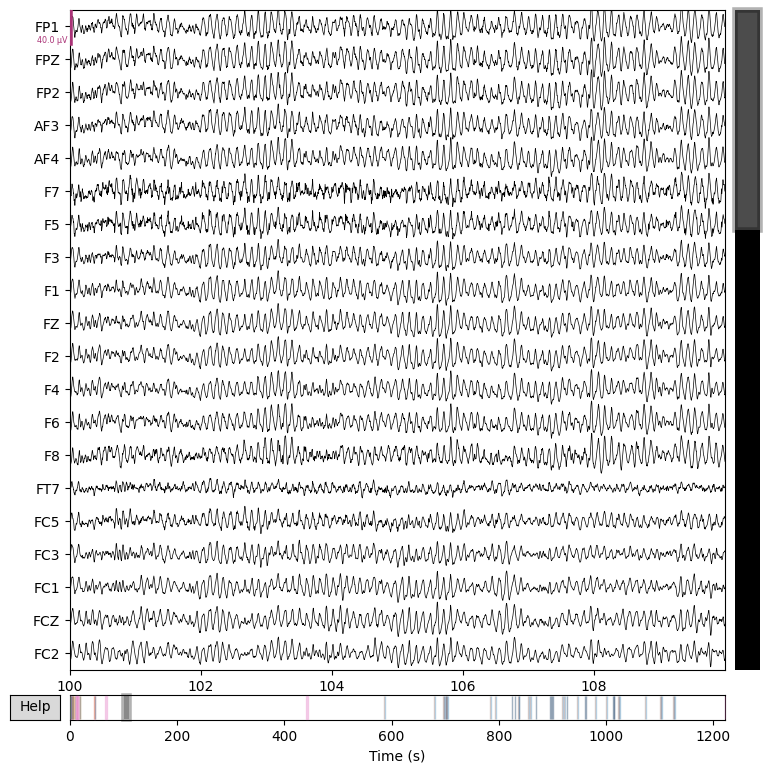

In [ ]:
# First plotting of the raw data

raw.plot(start=100, duration=10);

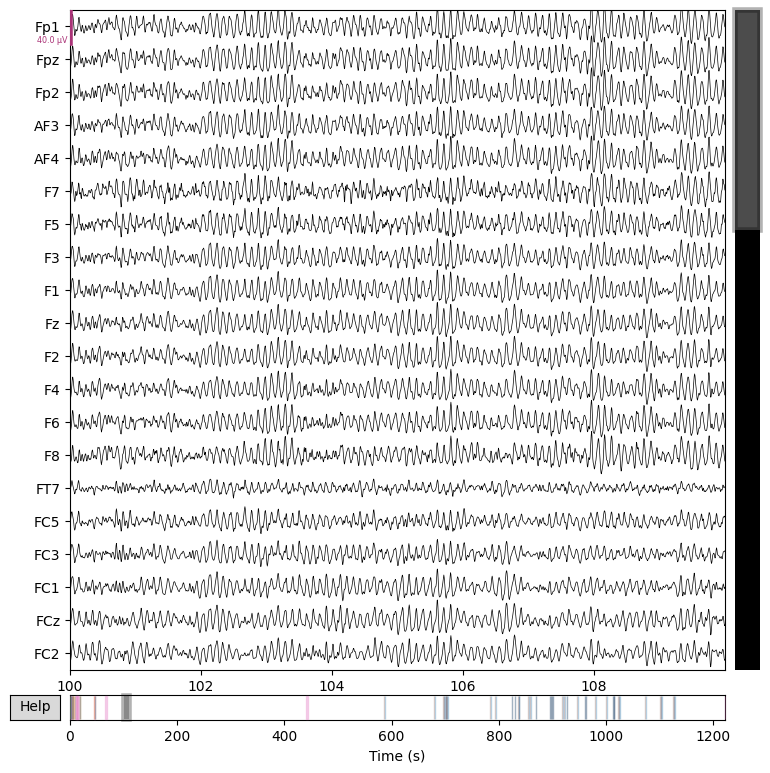

In [ ]:
# Plotting of the cleaned data
raw_clean_EEG = raw_clean.copy().filter(l_freq=1, h_freq=45,picks="eeg", verbose = False)
raw_clean_EEG.plot(start=100, duration=10);

## Power Spectral Density

Power spectral density (PSD) shows how signal power is distributed across frequencies. Instead of focusing on how the EEG changes over time, PSD highlights which frequency ranges contribute most strongly to the recording.

PSD is a common starting point in EEG analysis because it summarizes familiar brain rhythms such as delta, theta, alpha, beta, and gamma activity.

Common EEG frequency bands include:

| Band | Frequency range | Typical interpretation |
|---|---:|---|
| Delta | 1-4 Hz | Very slow activity, often prominent during sleep or drowsiness |
| Theta | 4-8 Hz | Often discussed in relation to attention, memory, or drowsiness |
| Alpha | 8-13 Hz | Common during relaxed wakefulness, especially with eyes closed |
| Beta | 13-30 Hz | Often associated with alert, cognitive, or motor processes |
| Gamma | 30+ Hz | Fast activity that can reflect neural activity but is also sensitive to muscle artifacts |

The next cells visualize the PSD, summarize power within these bands, and then map those values across the scalp.


Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


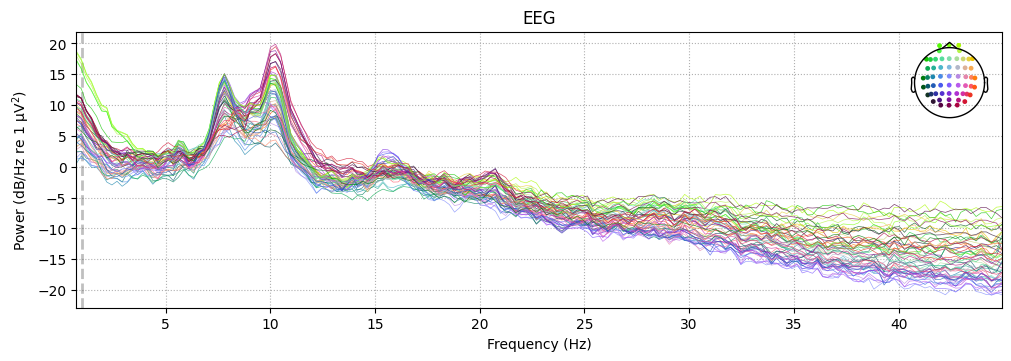

In [ ]:
raw_clean.compute_psd(fmin=0.5,fmax=45).plot(picks='eeg');

In [ ]:
raw_eeg = raw_clean.copy().pick("eeg")
psd = raw_eeg.compute_psd(method="welch", fmin=1, fmax=45, verbose=False)
psds, freqs = psd.get_data(return_freqs=True)

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

band_colors = {
    "delta": "#4477AA",
    "theta": "#66CCEE",
    "alpha": "#228833",
    "beta": "#CCBB44",
    "gamma": "#EE6677",
}


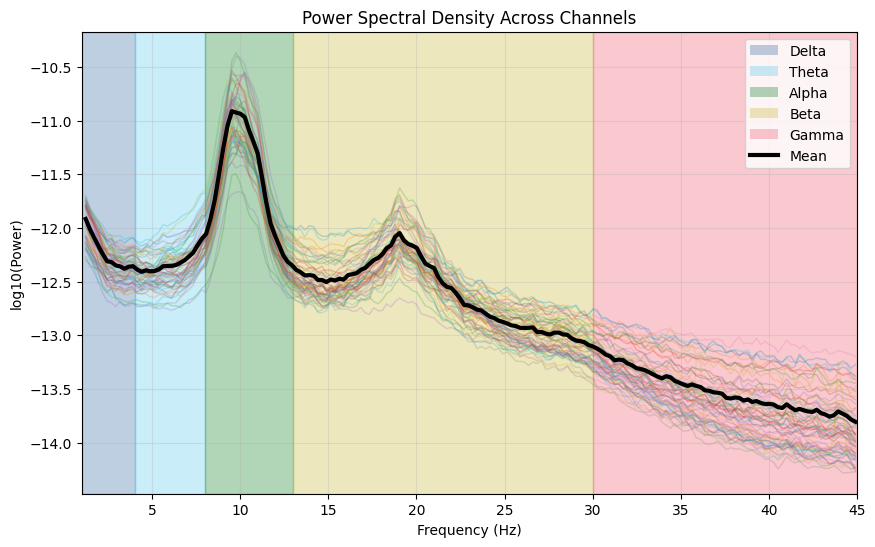

In [ ]:
plt.figure(figsize=(10, 6))

# Background frequency bands
for band, (fmin, fmax) in bands.items():
    plt.axvspan(fmin, fmax, color=band_colors[band], alpha=0.35)

# Plot each channel
for ch_idx, ch_name in enumerate(raw_clean.copy().pick("eeg").ch_names):
    plt.plot(freqs, np.log10(psds[ch_idx]), alpha=0.25, linewidth=1)

# Plot mean across channels
mean_psd = psds.mean(axis=0)
mean_line, = plt.plot(freqs, np.log10(mean_psd), color="black", linewidth=3, label="Mean")

band_handles = [
    Patch(facecolor=band_colors[band], alpha=0.35, label=band.capitalize())
    for band in bands.keys()
]

plt.xlabel("Frequency (Hz)")
plt.ylabel("log10(Power)")
plt.title("Power Spectral Density Across Channels")
plt.xlim(1, 45)
plt.grid(alpha=0.3)
plt.legend(handles=band_handles + [mean_line], loc="upper right")
plt.show()

## Extracting band power features

A common next step after computing the PSD is to summarize signal power within standard frequency bands such as delta, theta, alpha, beta, and gamma.

In the next cell, we compute both:

- **Absolute power**, which reflects the total power within a given frequency band
- **Relative power**, which expresses the power in a band as a proportion of the total power across the broader frequency range

This gives us simple channel-level features that can later be visualized across the scalp or used for statistical analysis.

In [ ]:
bandpower_features = []

total_mask = (freqs >= 1) & (freqs <= 45)
total_power = np.trapezoid(psds[:, total_mask], freqs[total_mask], axis=1)

for band, (fmin, fmax) in bands.items():
    band_mask = (freqs >= fmin) & (freqs <= fmax)

    absolute_power = np.trapezoid(
        psds[:, band_mask],
        freqs[band_mask],
        axis=1,
    )

    relative_power = np.divide(
        absolute_power,
        total_power,
        out=np.zeros_like(absolute_power),
        where=total_power != 0,
    )

    for ch_name, abs_val, rel_val in zip(raw_eeg.ch_names, absolute_power, relative_power):
        bandpower_features.append({
            "channel": ch_name,
            "band": band,
            "absolute_power": abs_val,
            "relative_power": rel_val,
        })

bandpower_df = pd.DataFrame(bandpower_features)

bandpower_df.head()


,channel,band,absolute_power,relative_power
0,Fp1,delta,1.844916e-12,0.050887
1,Fpz,delta,2.110638e-12,0.053091
2,Fp2,delta,2.017464e-12,0.052465
3,AF3,delta,1.854891e-12,0.056220
4,AF4,delta,1.887874e-12,0.054591


## Topographic maps

Topographic maps show how band power is distributed across the scalp.

In the figure below, the first row shows absolute power and the second row shows relative power for each frequency band.


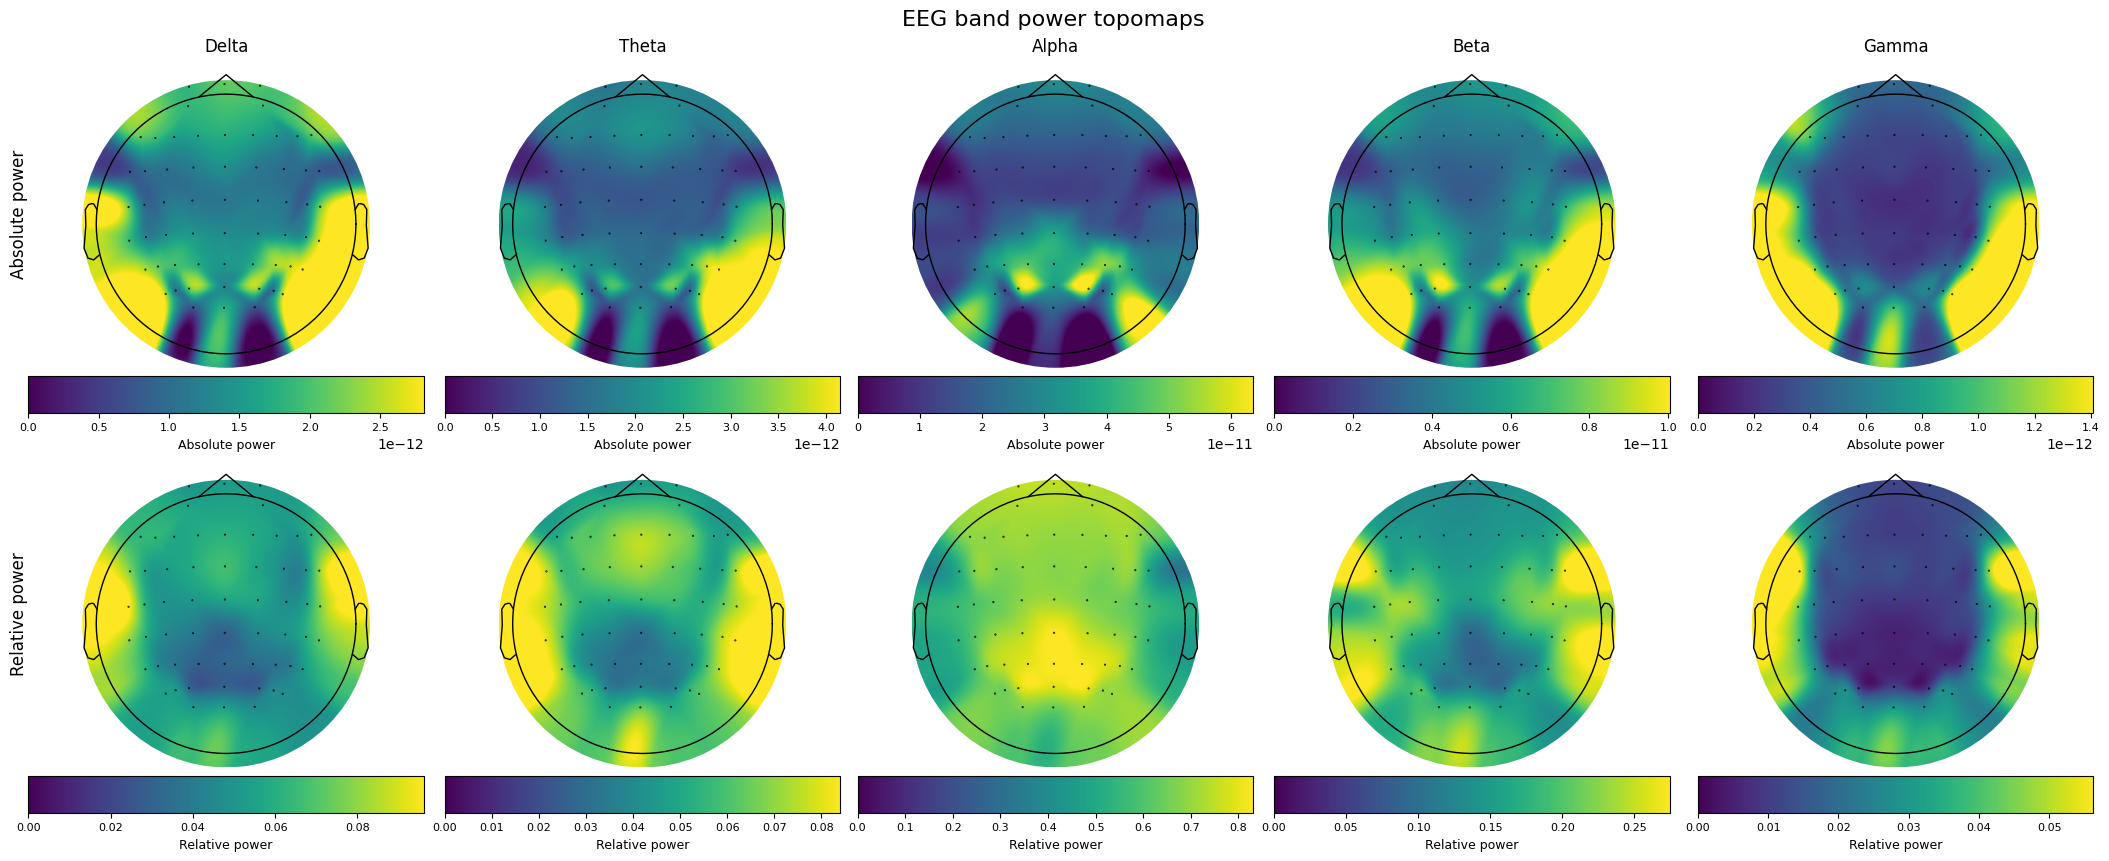

In [ ]:
band_order = list(bands.keys())
metrics = [
    ("absolute_power", "Absolute power"),
    ("relative_power", "Relative power"),
]

fig = plt.figure(figsize=(4.2 * len(band_order), 8.5), constrained_layout=True)
gs = fig.add_gridspec(
    nrows=4,
    ncols=len(band_order),
    height_ratios=[10, 1.2, 10, 1.2],
)

for row_idx, (metric, row_label) in enumerate(metrics):
    topo_row = row_idx * 2
    cbar_row = topo_row + 1

    for col_idx, band in enumerate(band_order):
        ax = fig.add_subplot(gs[topo_row, col_idx])
        cax = fig.add_subplot(gs[cbar_row, col_idx])

        band_df = bandpower_df[bandpower_df["band"] == band]
        values = np.array([
            band_df.loc[band_df["channel"] == ch, metric].values[0]
            for ch in raw_eeg.ch_names
        ])

        im, _ = mne.viz.plot_topomap(
            values,
            raw_eeg.info,
            axes=ax,
            show=False,
            contours=0,
            cmap="viridis",
        )

        if row_idx == 0:
            ax.set_title(band.capitalize(), fontsize=12)

        if col_idx == 0:
            ax.text(
                -0.22,
                0.5,
                row_label,
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=12,
            )

        cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
        cbar.set_label(row_label, fontsize=9)
        cax.tick_params(labelsize=8)

fig.suptitle("EEG band power topomaps", fontsize=16)
plt.show()


With Eyes-closed resting-state data, we expect alpha power to be dominating at the back of the head (occipital regions) which is what we see with these topomaps.

## Where to go from here

This notebook introduced a basic EEG workflow: loading data, applying simple preprocessing, inspecting the signal in time and frequency, and extracting band-power features.

Once the data has been cleaned and basic spectral features have been computed, EEG analysis can be extended in several directions depending on the research question.

Some common next steps include:

- **Time-frequency analysis** to study how oscillatory activity changes over time
- **Event-related analysis** using epochs and ERPs to compare responses across conditions
- **Functional connectivity and network analysis** to study relationships between channels or brain regions
- **Signal complexity analysis** using measures such as entropy, fractal metrics, or Lempel-Ziv complexity
- **Source-space analysis** to estimate where cortical activity may originate
- **Statistics and machine learning** for group comparisons, decoding, classification, or prediction

A few useful Python libraries for these more advanced steps are:

- **MNE-Python**, which remains the main library for EEG preprocessing, epoching, spectral analysis, topographic maps, and source reconstruction. Their website also contains a lot of tutorials.
- **SciPy** for signal-processing tools and statistical tests
- **statsmodels** for more advanced statistical modeling
- **mne-connectivity** for connectivity analyses
- **scikit-learn** for machine learning and decoding
- **nilearn** for visualization and analysis of source-space or brain-imaging data

For example, MNE can be used for source reconstruction with template anatomies such as `fsaverage`, which can be helpful when individual MRI data are not available. However, source analysis requires additional assumptions and should be interpreted with care.

This notebook is meant as a starting point. From here, the next steps depend on whether your goal is data quality assessment, feature extraction, group-level statistics, or more advanced modeling of brain dynamics.